In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [7]:
df['TotalCharges'].dtype

dtype('float64')

In [8]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [9]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

/var/folders/2q/vph7t8g13pd9cn6hfdjlkw4c0000gn/T/ipykernel_35136/1801685955.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


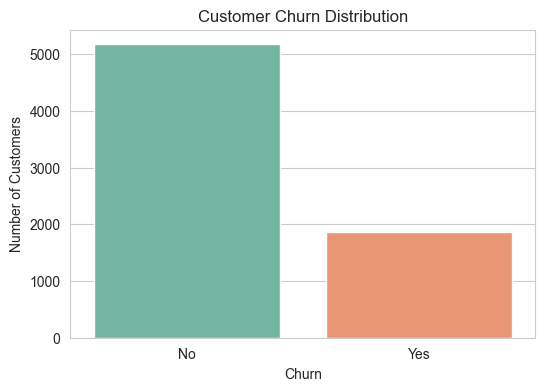

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

In [12]:
def tenure_bucket(t):
    if t <= 12:
        return '0-12 months'
    elif t <= 24:
        return '13-24 months'
    elif t <= 48:
        return '25-48 months'
    else:
        return '49+ months'

df['TenureBucket'] = df['tenure'].apply(tenure_bucket)
df[['tenure', 'TenureBucket']].head()

,tenure,TenureBucket
0,1,0-12 months
1,34,25-48 months
2,2,0-12 months
3,45,25-48 months
4,2,0-12 months


In [13]:
churn_by_tenure = df.groupby('TenureBucket')['Churn'].value_counts(normalize=True).unstack() * 100
churn_by_tenure

Churn,No,Yes
TenureBucket,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49+ months,90.486824,9.513176


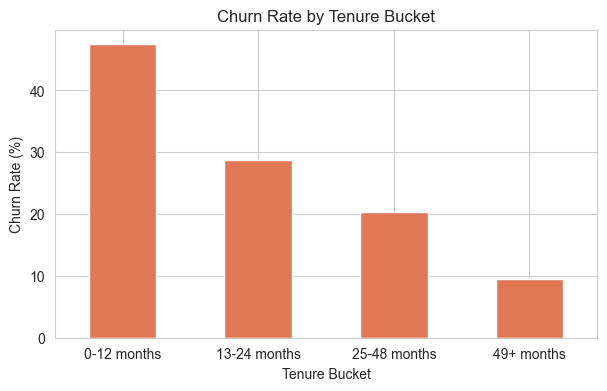

In [14]:
churn_by_tenure['Yes'].plot(kind='bar', figsize=(7,4), color='#e07856')
plt.title('Churn Rate by Tenure Bucket')
plt.xlabel('Tenure Bucket')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [15]:
churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


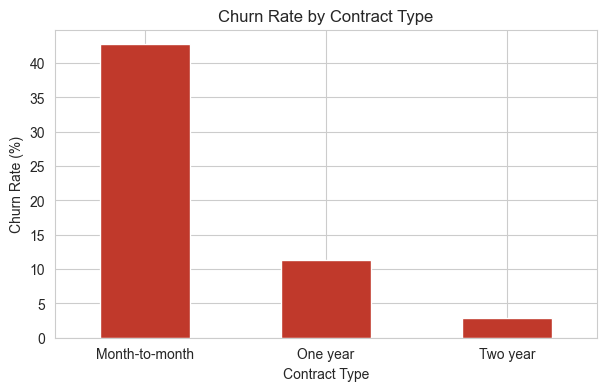

In [16]:
churn_by_contract['Yes'].plot(kind='bar', figsize=(7,4), color='#c0392b')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

## Key Findings — Initial EDA

- **Overall churn rate:** 26.5% of customers have churned.
- **Tenure is a strong driver:** churn rate drops from 47.4% (0-12 months) to 9.5% (49+ months) — new customers are ~5x more likely to churn than long-tenured ones.
- **Contract type is the strongest driver found so far:** month-to-month customers churn at 42.7%, versus 11.3% for one-year and just 2.8% for two-year contracts — a 15x difference between the extremes.
- **Data quality note:** `TotalCharges` was loaded as text due to 11 blank-string values, all belonging to customers with 0 months tenure. Converted to numeric and filled with 0, consistent with their tenure.

In [17]:
df.to_csv('../data/processed/telco_churn_cleaned.csv', index=False)

In [18]:
import sqlite3

conn = sqlite3.connect('../data/processed/churnlens.db')
df.to_sql('customers', conn, if_exists='replace', index=False)
conn.close()

In [19]:
conn = sqlite3.connect('../data/processed/churnlens.db')

test_query = "SELECT COUNT(*) AS total_customers FROM customers"
pd.read_sql(test_query, conn)

,total_customers
0,7043


In [20]:
conn.close()

In [21]:
conn = sqlite3.connect('../data/processed/churnlens.db')

with open('../sql/02_churn_trends.sql', 'r') as f:
    query = f.read()

result = pd.read_sql(query, conn)
result.head(15)

,tenure,total_customers,churned_customers,churn_rate_pct
0,0,11,0,0.00
1,1,613,380,61.99
2,2,238,123,51.68
3,3,200,94,47.00
4,4,176,83,47.16
5,5,133,64,48.12
6,6,110,40,36.36
7,7,131,51,38.93
8,8,123,42,34.15
9,9,119,46,38.66


In [22]:
with open('../sql/03_tenure_buckets.sql', 'r') as f:
    query = f.read()

result = pd.read_sql(query, conn)
result

,tenure_bucket,total_customers,churned_customers,churn_rate_pct
0,0-12 months,2186,1037,47.44
1,13-24 months,1024,294,28.71
2,25-48 months,1594,325,20.39
3,49+ months,2239,213,9.51


In [23]:
with open('../sql/04_service_usage.sql', 'r') as f:
    query = f.read()

result = pd.read_sql(query, conn)
result

,service,has_service,total_customers,churned_customers,churn_rate_pct
0,DeviceProtection,No,3095,1211,39.13
1,DeviceProtection,Yes,2422,545,22.50
2,OnlineBackup,No,3088,1233,39.93
3,OnlineBackup,Yes,2429,523,21.53
4,OnlineSecurity,No,3498,1461,41.77
5,OnlineSecurity,Yes,2019,295,14.61
6,TechSupport,No,3473,1446,41.64
7,TechSupport,Yes,2044,310,15.17


In [24]:
with open('../sql/05_contract_payment.sql', 'r') as f:
    query = f.read()

result = pd.read_sql(query, conn)
result

,Contract,PaymentMethod,total_customers,churned_customers,churn_rate_pct
0,Month-to-month,Electronic check,1850,994,53.73
1,Month-to-month,Bank transfer (automatic),589,201,34.13
2,Month-to-month,Credit card (automatic),543,178,32.78
3,Month-to-month,Mailed check,893,282,31.58
4,One year,Electronic check,347,64,18.44
5,One year,Credit card (automatic),398,41,10.30
6,One year,Bank transfer (automatic),391,38,9.72
7,One year,Mailed check,337,23,6.82
8,Two year,Electronic check,168,13,7.74
9,Two year,Bank transfer (automatic),564,19,3.37


In [25]:
df_encoded = df.copy()

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})

df_encoded['gender'] = df_encoded['gender'].map({'Male': 1, 'Female': 0})

df_encoded.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureBucket
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0-12 months
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,No,No,No,One year,0,Mailed check,56.95,1889.50,0,25-48 months
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0-12 months
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,25-48 months
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,0-12 months


In [26]:
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']

df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=True)

df_encoded.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False


In [27]:
correlations = df_encoded.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
correlations

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


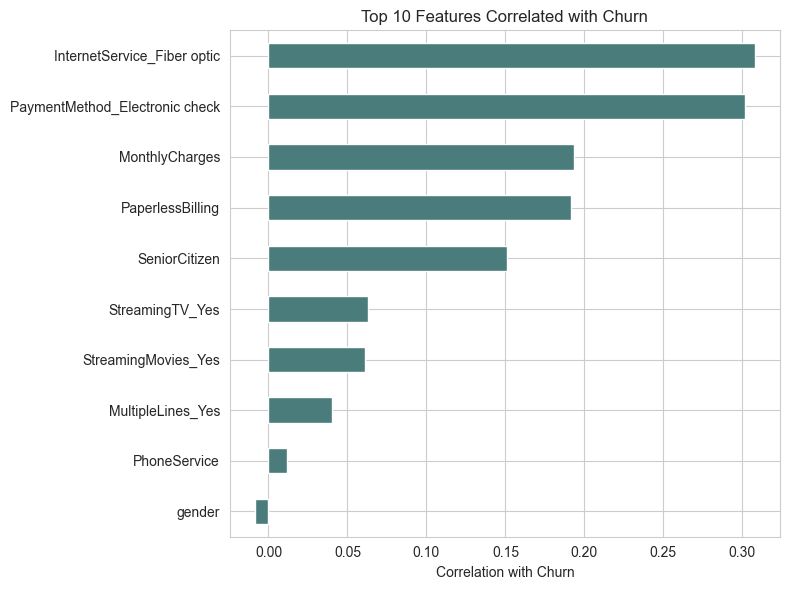

In [28]:
top_correlations = correlations.drop('Churn').head(10)

plt.figure(figsize=(8,6))
top_correlations.sort_values().plot(kind='barh', color='#4a7c7c')
plt.title('Top 10 Features Correlated with Churn')
plt.xlabel('Correlation with Churn')
plt.tight_layout()
plt.show()

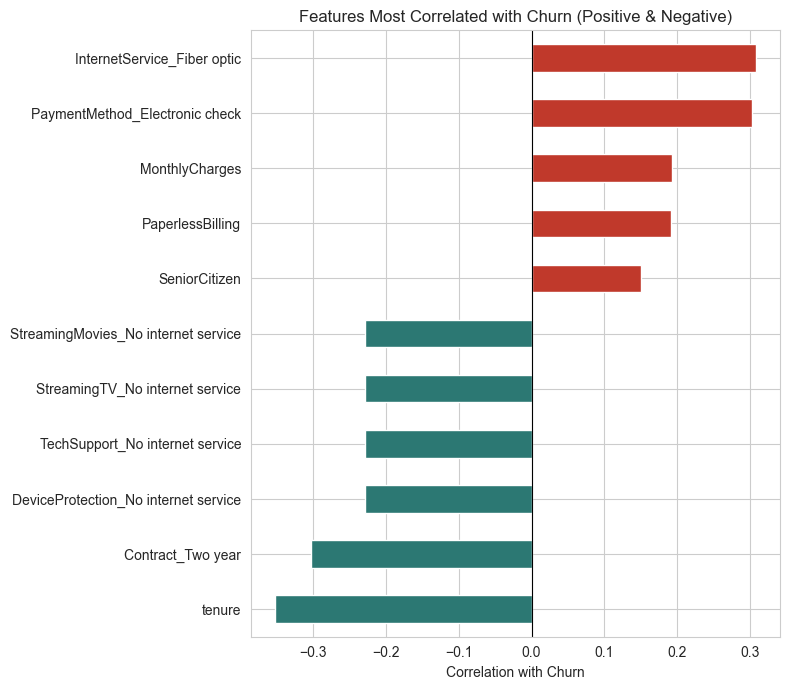

In [29]:
top_and_bottom = pd.concat([correlations.head(6), correlations.tail(6)]).drop('Churn')

plt.figure(figsize=(8,7))
top_and_bottom.sort_values().plot(kind='barh', color=top_and_bottom.sort_values().apply(lambda x: '#c0392b' if x > 0 else '#2c7873'))
plt.title('Features Most Correlated with Churn (Positive & Negative)')
plt.xlabel('Correlation with Churn')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

redundant_cols = [
    'OnlineSecurity_No internet service',
    'OnlineBackup_No internet service',
    'DeviceProtection_No internet service',
    'TechSupport_No internet service',
    'StreamingTV_No internet service',
    'StreamingMovies_No internet service',
    'MultipleLines_No phone service'
]

X = df_encoded.drop(columns=['customerID', 'Churn', 'TenureBucket'] + redundant_cols)

bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully")
print("Training accuracy:", model.score(X_train_scaled, y_train))
print("Test accuracy:", model.score(X_test_scaled, y_test))

Model trained successfully
Training accuracy: 0.8024494142705005
Test accuracy: 0.8211497515968772


/Users/drikshathakur/Documents/churnlens-customer-retention-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/drikshathakur/Documents/churnlens-customer-retention-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/drikshathakur/Documents/churnlens-customer-retention-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/drikshathakur/Documents/churnlens-customer-retention-analytics/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/drikshat

In [53]:
X.describe().T[['mean', 'std']].sort_values('std')

,mean,std
PhoneService,0.903166,0.295752
SeniorCitizen,0.162147,0.368612
Contract_One year,0.209144,0.406726
PaymentMethod_Credit card (automatic),0.216101,0.411613
InternetService_No,0.216669,0.412004
PaymentMethod_Mailed check,0.228880,0.420141
Contract_Two year,0.240664,0.427517
OnlineSecurity_Yes,0.286668,0.452237
TechSupport_Yes,0.290217,0.453895
Dependents,0.299588,0.458110


In [54]:
import numpy as np

X.isnull().sum().sum()

np.int64(0)

In [55]:
np.isinf(X.select_dtypes(include=[np.number])).sum().sum()

np.int64(0)

In [56]:
X.dtypes.value_counts()

int64      21
float64     2
Name: count, dtype: int64

In [57]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

perfect_pairs = [(col, row) for col in upper.columns for row in upper.index if upper.loc[row, col] > 0.999]
perfect_pairs

[]

In [58]:
perfect_pairs = [(col, row, upper.loc[row, col]) for col in upper.columns for row in upper.index if upper.loc[row, col] > 0.85]
perfect_pairs

[]

In [59]:
import numpy as np

rank = np.linalg.matrix_rank(X_train_scaled)
num_features = X_train_scaled.shape[1]

print("Number of features:", num_features)
print("Matrix rank:", rank)

Number of features: 23
Matrix rank: 23


In [60]:
print("NaNs in X_train_scaled:", np.isnan(X_train_scaled).sum())
print("Infs in X_train_scaled:", np.isinf(X_train_scaled).sum())
print("Max value in X_train_scaled:", X_train_scaled.max())
print("Min value in X_train_scaled:", X_train_scaled.min())

NaNs in X_train_scaled: 0
Infs in X_train_scaled: 0
Max value in X_train_scaled: 2.8270969616541186
Min value in X_train_scaled: -3.034225064020537


In [61]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning, module='sklearn')

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully")
print("Training accuracy:", model.score(X_train_scaled, y_train))
print("Test accuracy:", model.score(X_test_scaled, y_test))

Model trained successfully
Training accuracy: 0.8024494142705005
Test accuracy: 0.8211497515968772


In [62]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

coefficients

,Feature,Coefficient
8,TotalCharges,0.664127
10,InternetService_Fiber optic,0.597731
17,StreamingMovies_Yes,0.219750
16,StreamingTV_Yes,0.170198
6,PaperlessBilling,0.163998
9,MultipleLines_Yes,0.163769
21,PaymentMethod_Electronic check,0.152436
1,SeniorCitizen,0.058796
2,Partner,0.027246
14,DeviceProtection_Yes,0.023534


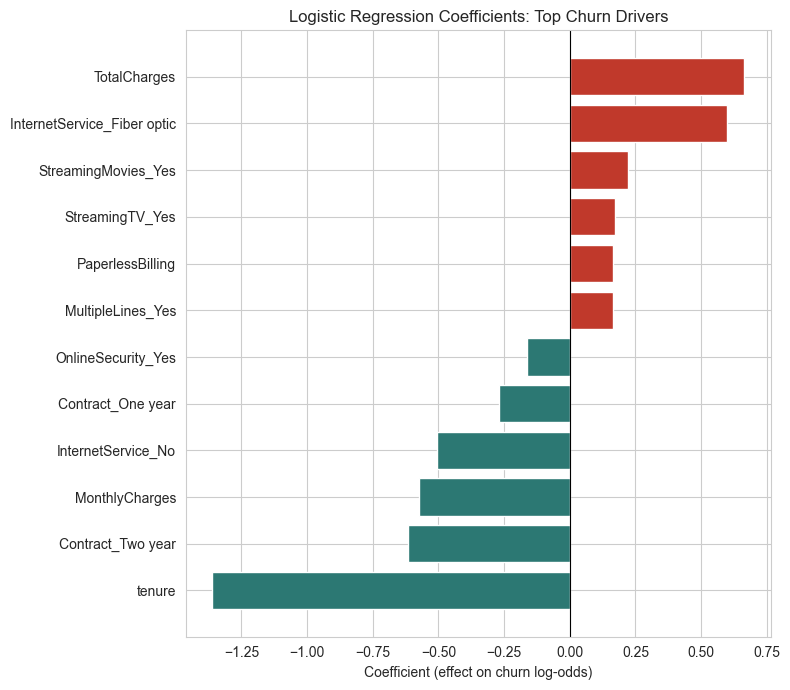

In [63]:
top_coefs = pd.concat([coefficients.head(6), coefficients.tail(6)])

plt.figure(figsize=(8,7))
colors = top_coefs['Coefficient'].apply(lambda x: '#c0392b' if x > 0 else '#2c7873')
plt.barh(top_coefs['Feature'], top_coefs['Coefficient'], color=colors)
plt.title('Logistic Regression Coefficients: Top Churn Drivers')
plt.xlabel('Coefficient (effect on churn log-odds)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Key Findings — Correlation & Logistic Regression

- **Tenure remains the single strongest churn driver** across every method used (EDA, SQL, correlation, and regression) — confirming this is the most reliable finding in the entire analysis.
- **Contract type is the second-strongest driver**: two-year contracts reduce churn odds substantially more than one-year contracts, consistent with SQL findings.
- **Fiber optic internet customers show independently higher churn risk**, even after controlling for other factors — suggesting a possible service quality or pricing issue worth investigating operationally.
- **Payment method's effect shrank once contract type was controlled for**: `PaymentMethod_Electronic check` was the #2 strongest factor in raw correlation, but a much smaller factor in the regression — its raw correlation was likely inflated by its overlap with month-to-month contracts.
- **Data caveat:** `TotalCharges`, `tenure`, and `MonthlyCharges` are mathematically related (TotalCharges ≈ tenure × MonthlyCharges), causing their regression coefficients to appear somewhat unstable/contradictory in isolation. `tenure` and `MonthlyCharges` are treated as the more reliable individual signals.
- **Model performance:** ~82% test accuracy — note this model was built for interpretability (ranking churn drivers), not for production-grade prediction.